# Screenshots

In [14]:
from tools import screenshot

In [15]:
image_path, img, cursor = screenshot.take_screenshot("test_screenshot")

Taking screenshot and saving to screenshots/20260321162347_test_screenshot.png
Screenshot saved to screenshots/20260321162347_test_screenshot.png


In [16]:
cursor

(238, 1181)

In [17]:
grid_image = screenshot.draw_grid(image_path)

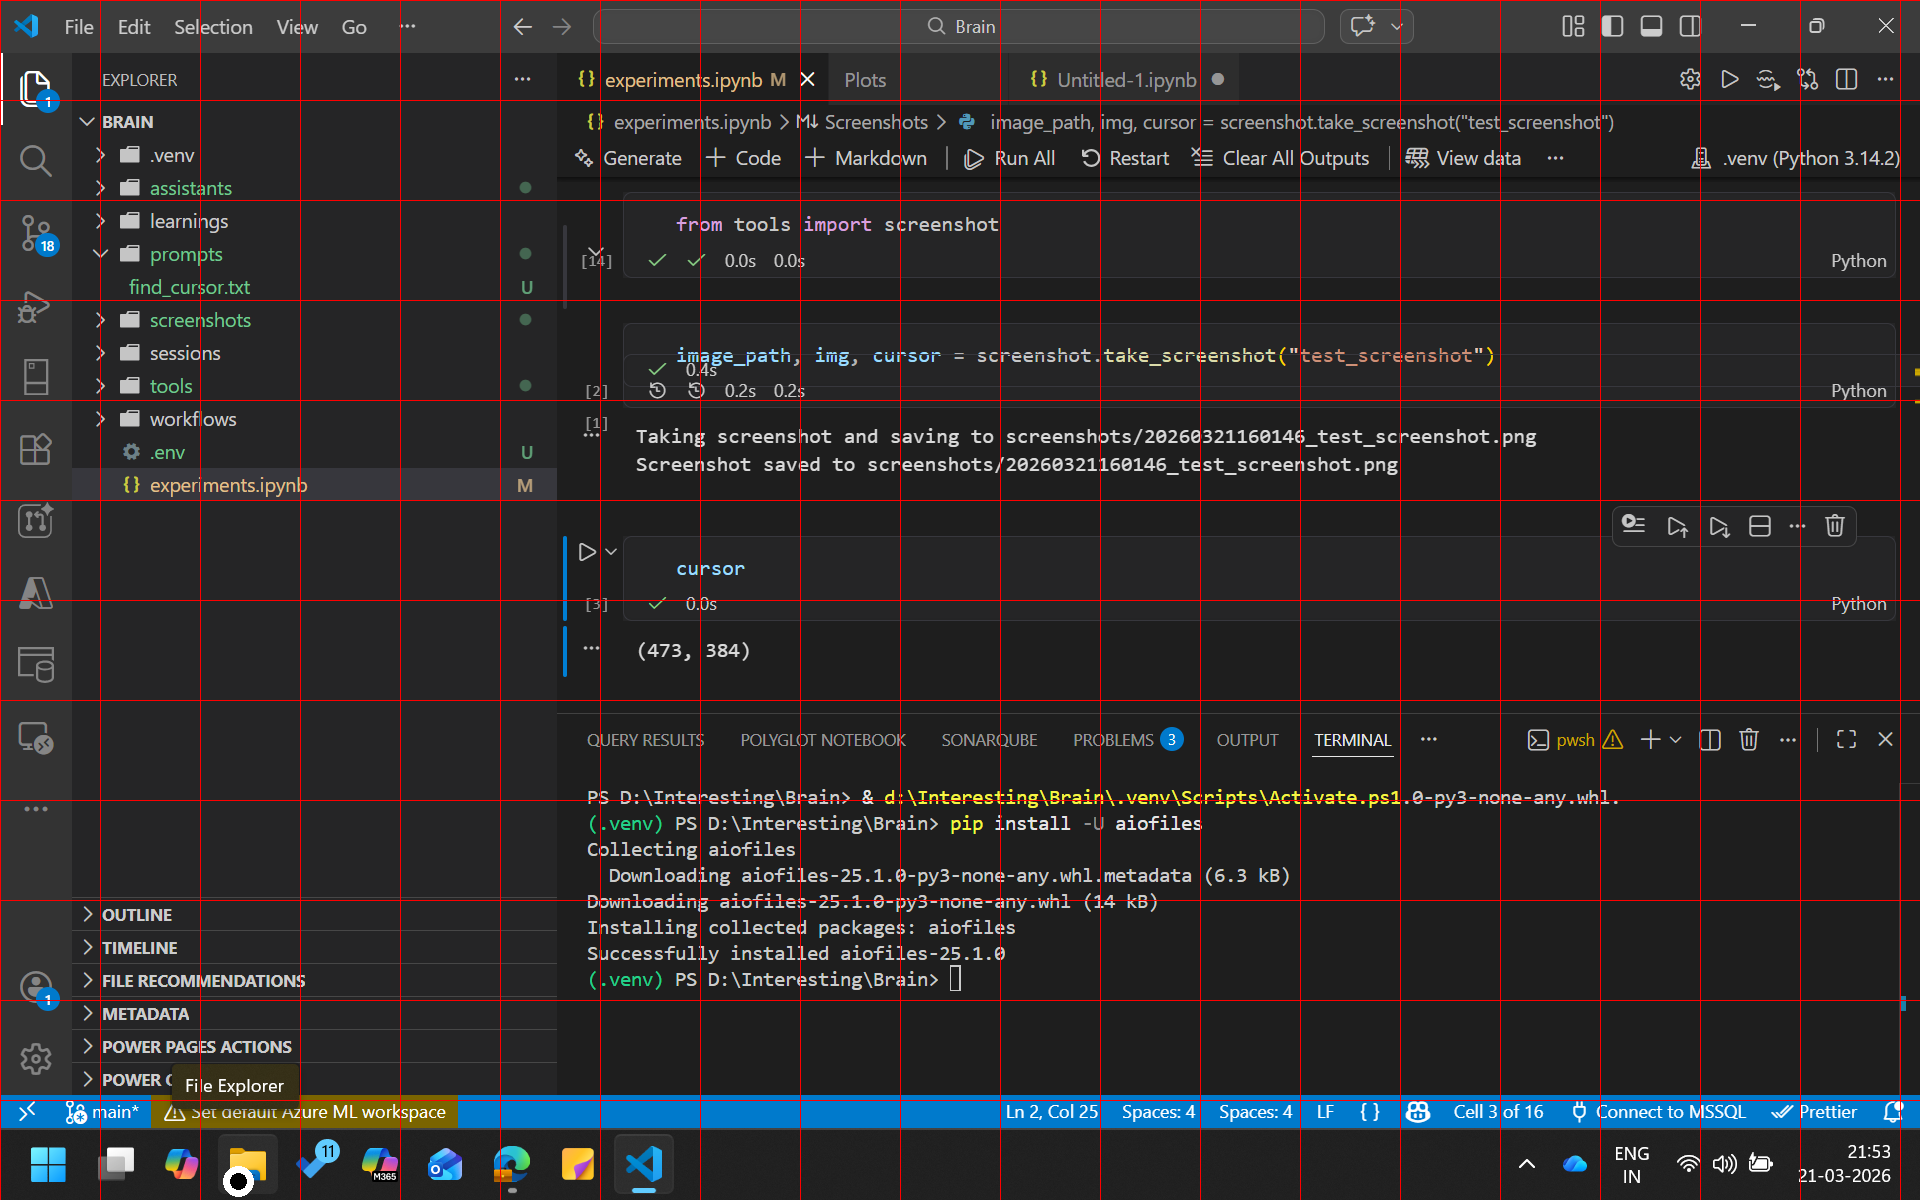

In [18]:
grid_image

# Microsoft Agent Framework

In [6]:
from agent_framework import Content, Message
from agent_framework.azure import AzureAIClient, AzureOpenAIResponsesClient
from azure.ai.projects.aio import AIProjectClient
from azure.identity.aio import VisualStudioCodeCredential

In [7]:
import json
import os
import io

import aiofiles
from dotenv import load_dotenv
from PIL import Image

In [8]:
load_dotenv()

True

In [9]:
assistants = [json.load(open(f"assistants/{file}")) for file in os.listdir("assistants")]

In [23]:
credential = VisualStudioCodeCredential()
async def main():
    # project_client = AIProjectClient(
    #         endpoint="https://susbi-poc-resource.services.ai.azure.com/api/projects/susbi-poc",
    #         credential=credential
    #     )

    # agent = AzureAIClient(
    #         project_client=project_client,
    #         model_deployment_name="Llama-4-Maverick-17B-128E-Instruct-FP8",
    #     ).as_agent(
    #         name="HelperAgent",
    #         instructions="You are a helpful assistant and you can process image inputs."
    #     )

    agent = AzureOpenAIResponsesClient(
            project_endpoint=os.environ["FOUNDRY_PROJECT_ENDPOINT"],
            deployment_name=os.environ["AZURE_OPENAI_RESPONSES_DEPLOYMENT_NAME"],
            credential=credential
        ).as_agent(
            name="HelperAgent",
            instructions="You are a helpful assistant and you can process image inputs."
        )
    
    ss = os.listdir("screenshots")[-1]
    print(ss)
    # async with aiofiles.open(f"screenshots\\{ss}", "rb") as f:
    #     image_bytes = await f.read()
    image = Image.open(f"screenshots/{ss}")
    width, height = image.size
    image_bytes_io = io.BytesIO()
    image.save(image_bytes_io, format="PNG")
    image_bytes = image_bytes_io.getvalue()

    message = Message(
        role="user",
        contents=[
            Content.from_text(text="""What should I do if I want to open Azure Portal based on my current screen state?
                              Please include all mouse and keyboard operations needed.
                              Make it a step wise approach including any pauses required between steps."""),
            Content.from_data(
                data=image_bytes,
                media_type="image/png"
            )
        ]
    )

    result = agent.run(message, stream=True)
    async for chunk in result:
        if chunk.text:
            print(chunk.text, end="", flush=True)
    # print(result)

    # await result.close()
    # await project_client.close()

In [24]:
await main()

20260321162347_test_screenshot.png
From your current screen (VS Code open on Windows), the quickest way is to open a browser and navigate to the Azure Portal.

Step‑by‑step:

1. Move your mouse to the **Windows taskbar at the bottom of the screen**.

2. Locate the **Microsoft Edge icon** (blue/green swirl icon near the middle of the taskbar).

3. **Left‑click the Microsoft Edge icon once.**

4. **Pause ~2 seconds** to allow the browser window to open.

5. When the browser appears, press **Ctrl + L** on your keyboard to focus the address bar.

6. Type:
   portal.azure.com

7. Press **Enter**.

8. **Pause 3–5 seconds** while the Azure Portal page loads.

9. If prompted, complete the **Microsoft sign‑in**:
   - Click the **Email/Phone field**
   - Type your Azure account email
   - Press **Enter**
   - Enter your password
   - Press **Enter** again.

10. **Wait 5–10 seconds** for the **Azure Portal dashboard** to load.

You should now be inside the **Azure Portal**.

## Vision call

---